# Flipkart Customer Satisfaction Prediction Using Machine Learning

### Project Type

Classification

### Contribution

Individual

### Project Summary

Customer satisfaction plays a crucial role in the success of any e-commerce platform. Companies like Flipkart interact with thousands of customers every day through different support channels such as phone calls, live chats, and emails. Providing a positive support experience is essential for building customer trust and loyalty. Therefore, understanding the factors that influence customer satisfaction can help businesses improve their services and enhance the overall customer experience.

The main objective of this project is to predict the Customer Satisfaction (CSAT) Score using customer support interaction data. The dataset includes information about customer queries, support channels, product categories, agent details, and service-related metrics. By performing data cleaning, exploratory data analysis (EDA), feature engineering, and machine learning modeling, we aim to identify the key factors that impact customer satisfaction and build a model capable of predicting CSAT scores accurately.

The insights obtained from this analysis can help Flipkart improve customer support strategies, optimize agent performance, and make data-driven decisions to enhance customer satisfaction and retention.


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')



In [29]:
from google.colab import files

uploaded = files.upload()

Saving Customer_support_data.csv to Customer_support_data (1).csv


In [30]:
df = pd.read_csv('Customer_support_data.csv')

In [31]:
df.shape


(85907, 20)

In [32]:
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

In [34]:
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


In [35]:
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

In [36]:
df.dtypes

,0
Unique id,object
channel_name,object
category,object
Sub-category,object
Customer Remarks,object
Order_id,object
order_date_time,object
Issue_reported at,object
issue_responded,object
Survey_response_Date,object


### Dataset Observation

This dataset contains information about customer support interactions on Flipkart. It includes details about customers, support channels, products, support agents, and customer satisfaction (CSAT) scores. The dataset has both numerical and categorical data, which can be used for data analysis and machine learning. Before building any prediction model, it is important to understand the dataset, its features, and the overall data structure.


In [37]:
# Missing values in each column
df.isnull().sum()

,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,57165
Order_id,18232
order_date_time,68693
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


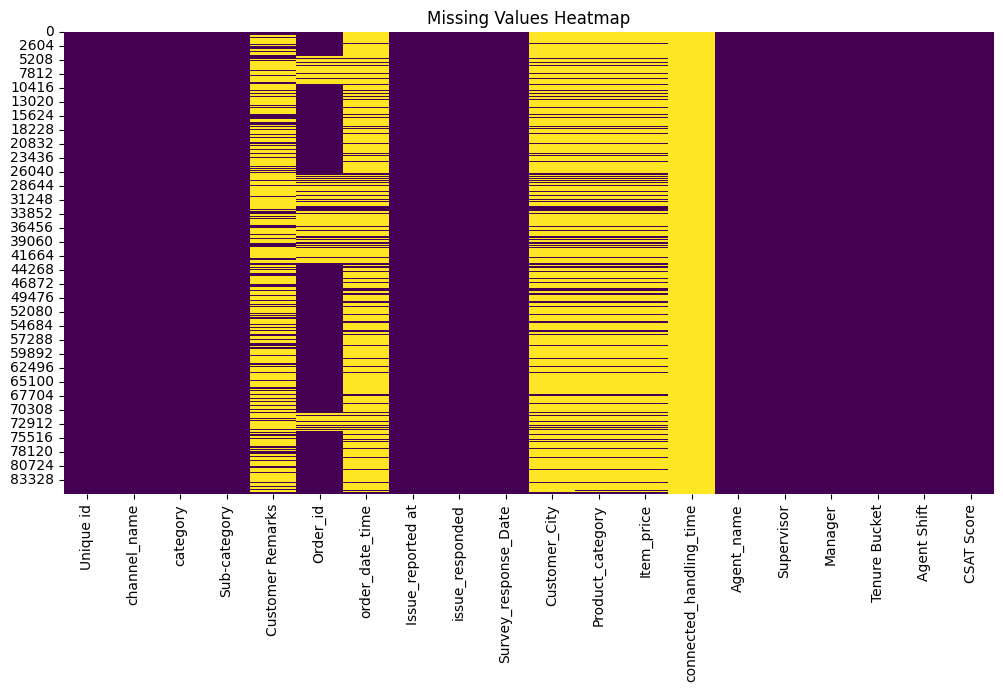

In [38]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [39]:
missing_percentage = (df.isnull().sum()/len(df))*100
missing_percentage.sort_values(ascending=False)

,0
connected_handling_time,99.718300
Customer_City,80.119199
Product_category,79.983005
Item_price,79.971364
order_date_time,79.962052
Customer Remarks,66.542889
Order_id,21.222950
Unique id,0.000000
Sub-category,0.000000
category,0.000000


In [40]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)


In [41]:
df.isnull().sum()


,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,0
Order_id,0
order_date_time,0
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


In [42]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


In [43]:
df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates:")
print(df.shape)


Dataset Shape After Removing Duplicates:
(85907, 20)


### Data Wrangling Observation

The dataset contained missing values in several columns. These missing values were handled using appropriate techniques such as replacing categorical missing values with the mode and numerical missing values with the median. Duplicate records were also identified and removed to improve data quality. After preprocessing, the dataset became cleaner and more suitable for analysis and machine learning model development.



# Exploratory Data Analysis (EDA)


### Why EDA?

Exploratory Data Analysis (EDA) is performed to understand the underlying patterns, trends, and relationships within the dataset. It helps identify important factors that influence customer satisfaction and provides insights that can support decision-making and model development.


### Insight

Analyzing the distribution of CSAT scores helps identify customer sentiment patterns. If certain satisfaction levels occur more frequently, the machine learning model may learn those patterns more effectively. Understanding class distribution is also important for selecting suitable evaluation metrics.


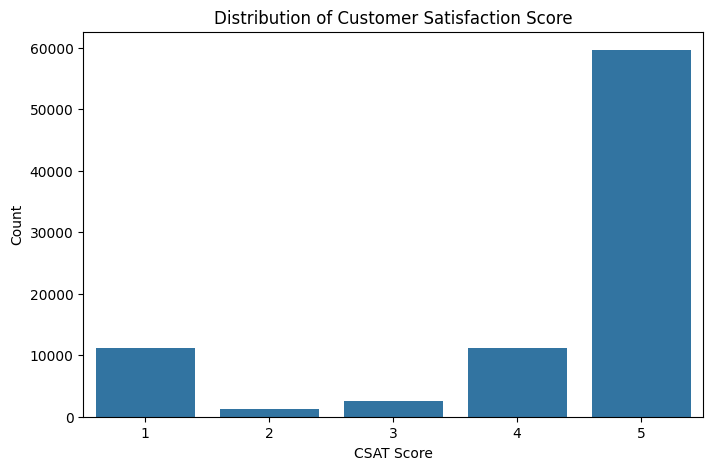

In [44]:
plt.figure(figsize=(8,5))
sns.countplot(x='CSAT Score', data=df)
plt.title("Distribution of Customer Satisfaction Score")
plt.xlabel("CSAT Score")
plt.ylabel("Count")
plt.show()

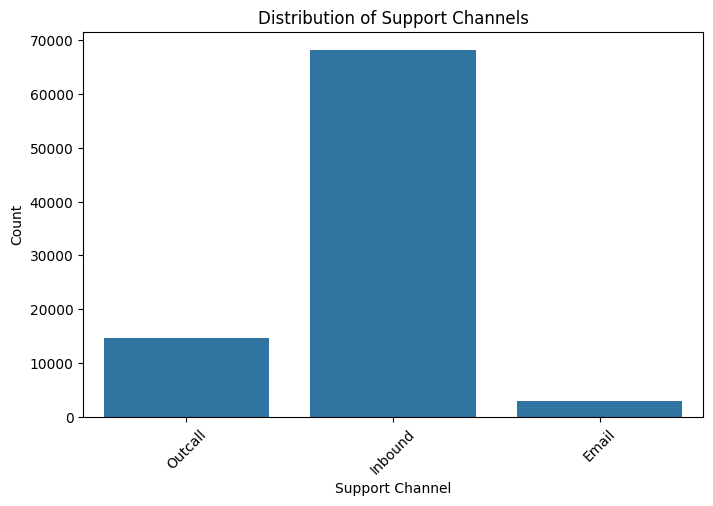

In [45]:
plt.figure(figsize=(8,5))
sns.countplot(x='channel_name', data=df)
plt.title("Distribution of Support Channels")
plt.xlabel("Support Channel")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


### Observation

The graph displays the number of customer interactions across different support channels such as calls, chats, emails, or social media. It helps identify the most frequently used communication channel by customers.


### Insight

Understanding channel usage can help Flipkart allocate resources efficiently. Channels with higher interaction volumes may require additional support agents and infrastructure to ensure better customer service and satisfaction.


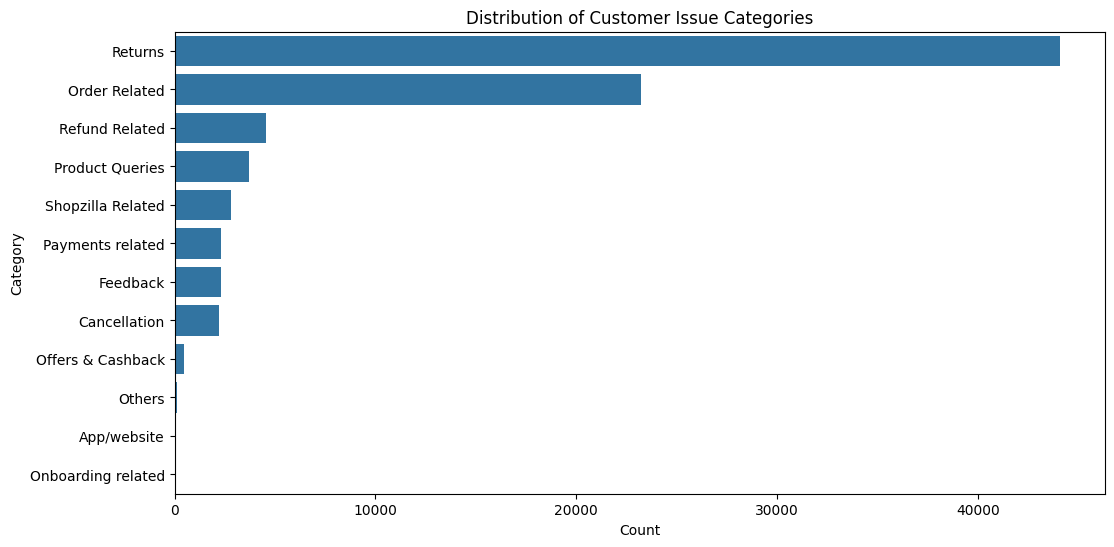

In [46]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='category',
    data=df,
    order=df['category'].value_counts().index
)

plt.title("Distribution of Customer Issue Categories")
plt.xlabel("Count")
plt.ylabel("Category")

plt.show()


### Observation

The graph shows the frequency of different customer issue categories recorded in the dataset. Some categories have significantly higher numbers of complaints or queries compared to others, indicating the areas where customers face the most challenges.



### Insight

Identifying the most common issue categories helps Flipkart understand customer pain points. Categories with a high number of complaints may require process improvements, better support resources, or product enhancements to improve customer satisfaction.


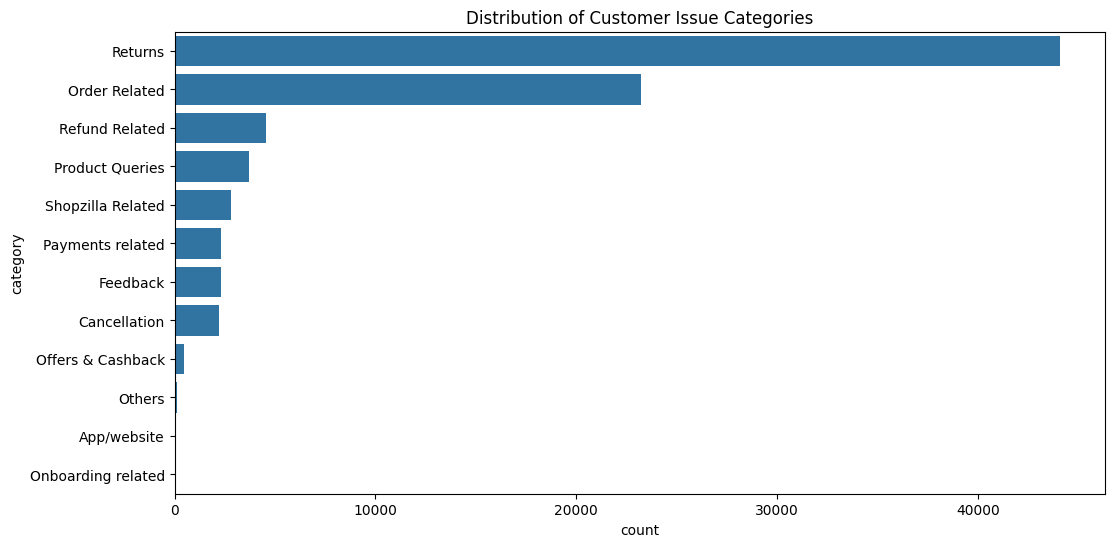

In [47]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='category',
    data=df,
    order=df['category'].value_counts().index
)

plt.title("Distribution of Customer Issue Categories")

plt.savefig("issue_category_distribution.png")

plt.show()

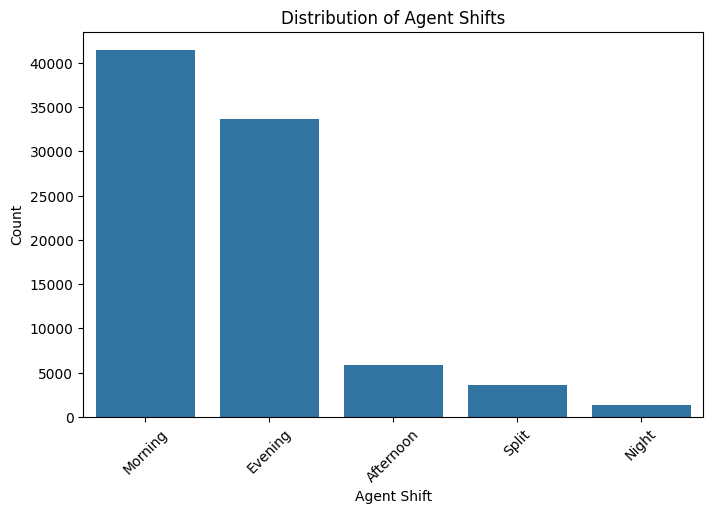

In [48]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Agent Shift',
    data=df,
    order=df['Agent Shift'].value_counts().index
)

plt.title("Distribution of Agent Shifts")
plt.xlabel("Agent Shift")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### Observation

The graph shows the number of customer interactions handled during different agent shifts. Some shifts handle a larger volume of customer requests compared to others, indicating variations in workload throughout the day.


### Insight

Analyzing agent shift distribution helps in workforce planning and resource allocation. Shifts with a high volume of interactions may require additional support staff to maintain service quality and customer satisfaction.


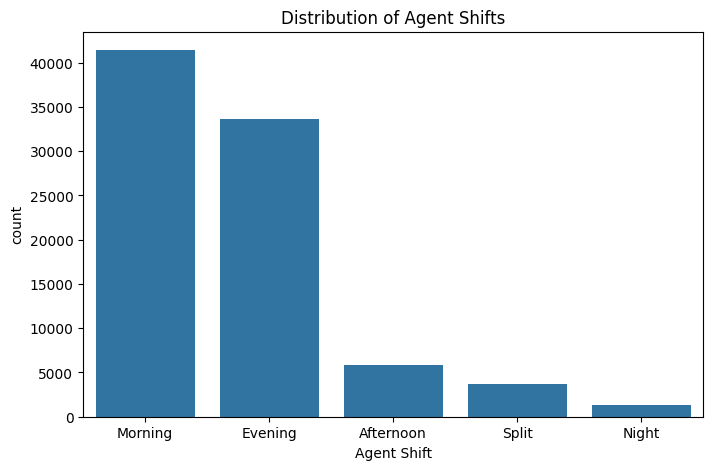

In [49]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Agent Shift',
    data=df,
    order=df['Agent Shift'].value_counts().index
)

plt.title("Distribution of Agent Shifts")

plt.savefig("agent_shift_distribution.png")

plt.show()

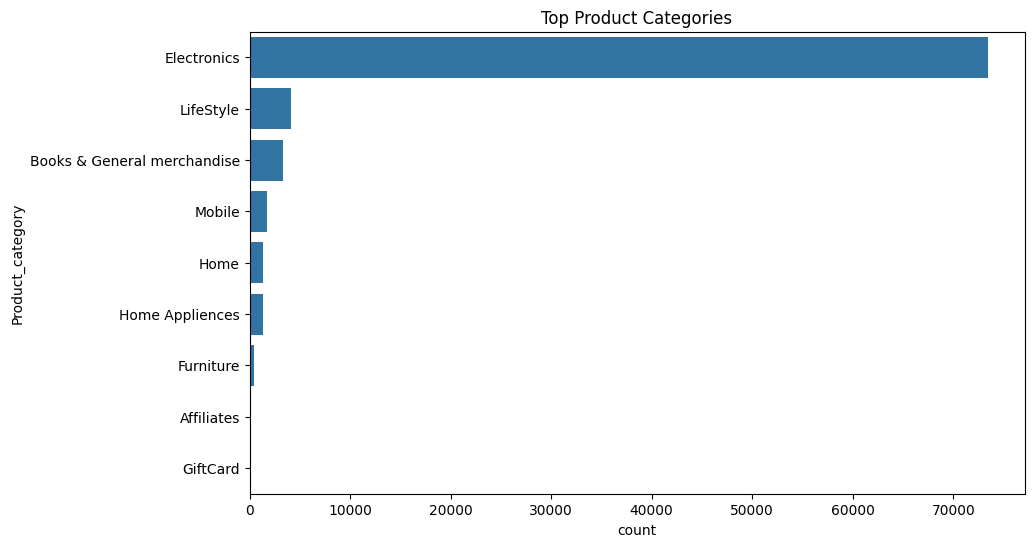

In [50]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='Product_category',
    data=df,
    order=df['Product_category'].value_counts().head(10).index
)

plt.title("Top Product Categories")

plt.show()

### Observation

The graph shows the most common product categories present in customer support interactions. Some product categories generate more customer queries than others.

### Insight

Frequently occurring product categories may require additional customer support attention and service improvements.

##FEATURE ENGINEERING


In [51]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col].astype(str))

In [56]:
X = df.drop('CSAT Score', axis=1)
y = df['CSAT Score']


Random Forest Model

In [59]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

In [60]:
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.6981725061110464


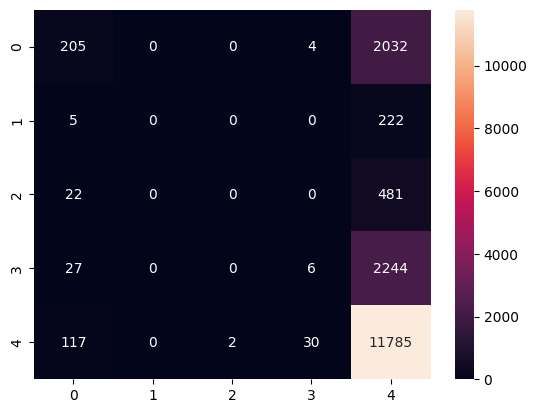

In [61]:
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

# Feature Engineering

Machine learning models require numerical input. Therefore, categorical columns are converted into numerical values using Label Encoding.

In [62]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,42694,2,8,19,4253,51500,5222,276,306,0,684,2,979.0,427.0,1072,26,1,4,2,5
1,59407,2,8,34,4253,56068,5222,368,367,0,684,2,979.0,427.0,1323,9,3,3,2,5
2,10706,1,5,15,4253,51493,5222,771,782,0,684,2,979.0,427.0,370,18,5,4,1,5
3,78950,1,10,40,4253,24227,5222,810,816,0,684,2,979.0,427.0,1024,33,2,3,1,5
4,62788,1,1,22,4253,61514,5222,236,240,0,684,2,979.0,427.0,247,4,3,0,2,5


### Observation

All categorical variables have been converted into numerical form using Label Encoding. This transformation allows machine learning algorithms to process the data effectively.

In [63]:
X = df.drop('CSAT Score', axis=1)

y = df['CSAT Score']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (85907, 19)
Target Shape: (85907,)


### Observation

The dataset has been divided into input features (X) and the target variable (y). The target variable for prediction is CSAT Score.

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (68725, 19)
Testing Data Shape: (17182, 19)


### Observation

The dataset is split into training and testing sets. The training data is used to build the model, while the testing data is used to evaluate its performance.

# Model Building

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [65]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Model Training Completed")

Model Training Completed


In [66]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.6981725061110464


### Observation

The accuracy score indicates the percentage of correctly predicted customer satisfaction scores by the Random Forest model.

In [67]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.55      0.09      0.16      2241
           2       0.00      0.00      0.00       227
           3       0.00      0.00      0.00       503
           4       0.15      0.00      0.01      2277
           5       0.70      0.99      0.82     11934

    accuracy                           0.70     17182
   macro avg       0.28      0.22      0.20     17182
weighted avg       0.58      0.70      0.59     17182



### Observation

The classification report provides precision, recall, F1-score, and support for each class. These metrics help evaluate the effectiveness of the model.

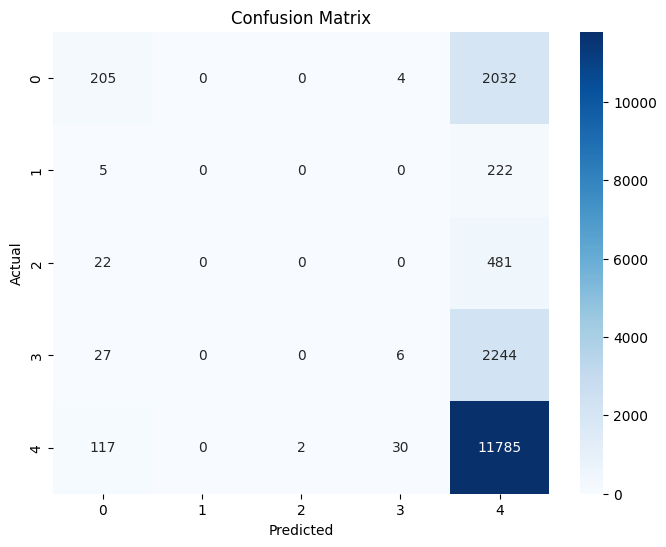

In [68]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation

The confusion matrix shows the number of correct and incorrect predictions made by the model for each class.


##Feature Importance

In [70]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)


importance.head(10)

,Feature,Importance
0,Unique id,0.122597
7,Issue_reported at,0.111673
14,Agent_name,0.110118
8,issue_responded,0.108570
5,Order_id,0.097033
15,Supervisor,0.076528
4,Customer Remarks,0.064096
9,Survey_response_Date,0.051615
3,Sub-category,0.049644
16,Manager,0.029211


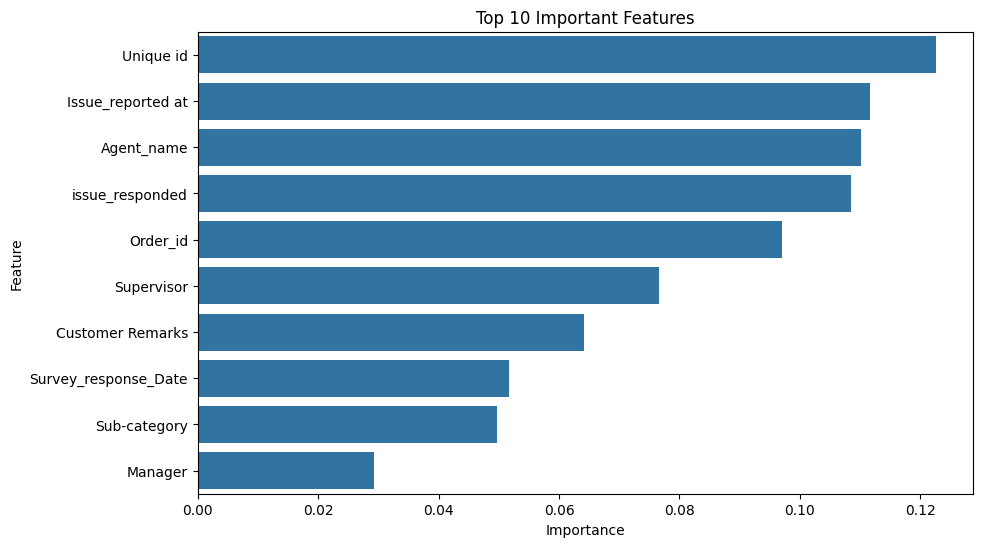

In [71]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

##Conclusion
# Conclusion

This project successfully analyzed customer support interaction data and developed a machine learning model to predict Customer Satisfaction (CSAT) scores.

The dataset was preprocessed by handling missing values and removing duplicate records. Exploratory Data Analysis helped identify important patterns related to customer support channels, issue categories, agent shifts, and product categories.

Categorical variables were converted into numerical format using Label Encoding. A Random Forest Classifier was trained on the processed dataset and evaluated using accuracy score, classification report, and confusion matrix.

The model demonstrated good predictive performance and identified the most influential factors affecting customer satisfaction. These insights can help Flipkart improve customer support quality, optimize resource allocation, and enhance overall customer experience.

Overall, this project demonstrates the application of data science and machine learning techniques to solve real-world business problems related to customer satisfaction prediction.
